# Laporan Simulasi Pengelolaan Sampah Desa

Disusun kelompok 9:

Nabilah Robbaniyah 
103072400092
Kholifa Ayu Lestari 
10307200114
Afiya Nadifa Febianti 
103072400036

Mata Kuliah: Dasar Kecerdasan Artifisial

# BAB I PENDAHULUAN

## 1.1 Latar Belakang

Sampah merupakan salah satu permasalahan lingkungan yang terus meningkat seiring bertambahnya jumlah penduduk dan aktivitas masyarakat. Pengelolaan sampah yang kurang efektik dapat menyebabkan penumpukan sampah, pencemaran lingkungan, serta menurunkan kualitas kesehatan masyarakat. Oleh karena itu, diperlukan sistem pengangkutan sampah yang terorganisir dan efisien agar proses pengumpulan serta pemindahan sampah dapat dilakukan dengan baik.
Pada tugas ini dilakukan simulasi sitem pengangkutan sampah pada lingkungan yang terdiri dari 100 rumah dengan menggunakan beberapa gerobak dan truk sampah. Simulasi dilakukan dengan memperhatikan kapasitas kendaraan, jumlah sampah yang dihasilkan setiap rumah, jarak antar rumah, serta waktu operasional kendaraan. Hasil simulasi ini diharapkan dapat memberikan gambaran menentukan rute pengangkutan sampah dan mengetahui apakah seluruh sampah dapat diangkut dalam batas waktu yang tersedia.
.

## 1.2 Rumusan Masalah

1. Bagaimana merancang sistem pengangkutan sampah untuk 100 rumah menggunakan gerobak dan truk sampah?
2. Bagaimana menerapkan algoritma Nearest Neighbor untuk menentukan rute pengangkutan sampah yang efisien?
3. bagaimana mensimulasikan proses pengangkutan sampah dari TPS menggunakan truk
4. menampilkan visualisasi graph dan jalur kendaraan dalam sistem



## 1.3 Tujuan

1. membuat model sistem pengelolaan sampah berbasis graph
2. mengimplementasikan algoritma Uniform Cost Search (UCS) untuk mencari jalur pendek
3. mensimulasikan proses pengumpulan sampah dari rumah ke TPS menggunakan gerobak.
4. mensimulasikan proses pengangkutan sampah dari TPS menggunakan truk.
5. menampilkan visualisasi graph serta jalur kendaraan yang digunakan selama simulasi berlangsung.

## 1.4 Manfaat

1. menambah pemahaman mengenai penerapan Kecerdasan Artifisial dalam permasalahan dunia nyata
2. paham konsep graph dan Algoritma Uniform Cost Search (UCS)


# BAB II ANALISIS DAN PERANCANGAN SISTEM

## 2.1 Analisis Sistem

Sistem yang dirancang merupakan simulasi pengelolaan sampah pada sebuah desa yang terdiri dari 100 rumah penduduk, 3 Tempat Pembuangan Sampah (TPS), beberapa gerobak sampah, dan beberapa truk sampah. Alur pengelolaan sampah yang digunakan adalah Rumah → Gerobak → TPS. Setiap rumah menghasilkan sampah harian antara 0–7 kg. Gerobak bertugas mengumpulkan sampah dari rumah-rumah dan mengantarkannya ke TPS terdekat. Seluruh proses pencarian rute dilakukan menggunakan algoritma Uniform Cost Search (UCS) untuk memperoleh jalur dengan biaya perjalanan minimum. Struktur simulasi dan pembagian komponennya mengikuti rancangan pada laporan yang telah dibuat.

## 2.2 Aturan Simulasi
| Parameter |  nilai |
|-------|----------|
| Jumlah rumah | 100 rumah |
| Jumlah TPS |  3 TPS |
| Jumlah Gerobak | 5-7 unit |
| Jumlah Truk | 2-4 unit |
| Kapasitas gerobak | 15 kg |
| Kapasitas truk | 200 kg |
| Kapasitas TPS | 400 - 500 kg |
| sampah per rumah | 0-7 kg |
| jam operasional gerobak | 06.00-15.00 |
| jam operasional truk | 08.00-17.00 |
| waktu loading gerobak | 2 menit/kg |
| waktu load truk | 2 menit/ 10 kg |
| waktu perjalanan truk | 3 menit/ 5 satuan jarak |
| waktu perjalanan gerobak | 3 menit / satuang jarak |

Parameter tersebut diimplementasikan pada program simulasi untuk menghitung waktu perjalanan, kapasitas kendaraan, serta sisa sampah setelah operasi berakhir.


## 2.3 Struktur Data

Objek House digunakan untuk merepresentasikan rumah penduduk. Setiap rumah memiliki:
1. ID rumah
2. jumlah sampah harian
3. koordinat posisi pada peta

TPS 
objek TPS digunakan untuk mempresentasikan Tempat pembuangan sampah. atribut TPS meliputi :
1. ID TPS
2. Kapasitas TPS
3. Jumlah sampah

Vehicle 
objek vehicle digunakan untuk mempresentasikan gerobak maupun truk. atribut yang digunakan:
1. Nama kendaraan
2. Jenis kendaraan
3. TPS asal
4. posisi saat ini
5. Muatan kendaraan
6. Total jarak tempuh
7. Waktu operasi

Struktur data ini memudahkan proses simulasi, pencatatan aktivitas kendaraan, dan pembuatan laporan hasil pengangkutan.


## 2.4 Flowchart Sistem


```mermaid
flowchart TD
    A([Mulai])
    B[Generate Rumah dan TPS]
    C[Membentuk Graph Desa]
    D[Menentukan Zona TPS Terdekat]
    E[Cari Rumah Tujuan dengan UCS]
    F[Gerobak Bergerak ke Rumah]
    G[Ambil Sampah]
    H[Menuju TPS]
    I[Buang Sampah ke TPS]
    J{Masih Ada Waktu Operasi?}
    K[Cetak Laporan]
    L([Selesai])

    A --> B
    B --> C
    C --> D
    D --> E
    E --> F
    F --> G
    G --> H
    H --> I
    I --> J
    J -- Ya --> E
    J -- Tidak --> K
    K --> L
```

# BAB III CODE

## 3.1 Import Library

In [15]:
import random
import heapq
import math 


Library random digunakan untuk menghasilkan data acak seperti jumlah sampah dan koneksi graph. Library heapq digunakan dalam implementasi Uniform Cost Search (UCS) untuk mengelola priority queue. Library math digunakan untuk perhitungan matematis.

## 3.2 Parameter Simulasi

In [16]:
jumlah_rumah = 100
jumlah_tps = 3
total_gerobak = random.randint(5, 7)
total_truk = random.randint(2, 4)
kapasitas_gerobak = 15
kapasitas_truk = 200
gerobak_mulai = 6 * 60
gerobak_selesai = 15 * 60
truk_mulai = 8 * 60
truk_selesai = 17 * 60

Parameter simulasi digunakan untuk menentukan jumlah rumah, jumlah TPS, jumlah kendaraan, kapasitas angkut, dan jam operasional kendaraan yang digunakan dalam proses pengangkutan sampah.

## 3.3 Definisi Kelas

In [17]:
class House:
    def __init__(self, id):
        self.id = f"H{id}"
        self.x = random.randint(0,100)
        self.y = random.randint(0,100)
        self.waste = random.randint(0,7) 
class TPS:
    def __init__(self, id):
        self.id = id
        self.x = random.randint(0,100)
        self.y = random.randint(0,100)
        self.capacity = random.randint(400,500)
        self.current = 0

# untuk assignment rumah ke truk/gerobak
class Vehicle:
    def __init__(self, name, vtype, home_tps):
        self.name = name
        self.vtype = vtype
        self.home_tps = home_tps # zona utamanya
        self.position = home_tps
        self.load = 0 # isi muatan saat ini
        self.cargo_detail = {}
        self.distance = 0
        self.time_used = 0
        self.log = []
        self.start_time = gerobak_mulai if vtype == "gerobak" else truk_mulai
    def free_capacity(self): # sisa kapasitas yang bisa diisi
        if self.vtype == "gerobak":
            return kapasitas_gerobak - self.load
        return kapasitas_truk - self.load

Kelas House digunakan untuk merepresentasikan rumah penduduk yang menghasilkan sampah. Setiap rumah memiliki identitas unik dan jumlah sampah yang dihasilkan secara acak.

Kelas TPS digunakan untuk merepresentasikan Tempat Pembuangan Sementara yang memiliki kapasitas maksimum serta jumlah sampah yang sedang tersimpan.

Kelas Vehicle digunakan untuk merepresentasikan kendaraan pengangkut sampah, baik gerobak maupun truk. Setiap kendaraan memiliki informasi posisi, kapasitas muatan, jarak tempuh, waktu operasional, serta riwayat aktivitas selama simulasi berlangsung.

## 3.4 Pembentukan Graph

In [ ]:
# buat graph
graph = {}
all_nodes = []
houses = [House(i) for i in range(jumlah_rumah)]
total_sampah_awal = sum(h.waste for h in houses)
tps_nodes = [TPS(f"TPS{i}") for i in range(jumlah_tps)]
all_nodes.extend(houses)
all_nodes.extend(tps_nodes)
for node in all_nodes: # inisialisasi graph
    graph[node.id] = []
for node in all_nodes:
    neighbors = random.sample(
        [n for n in all_nodes if n.id != node.id],
        random.randint(2, 5)
    )
    for nb in neighbors:
        euclid = math.sqrt(
            (node.x - nb.x)**2 +
            (node.y - nb.y)**2
        )
        d = max(1, min(5, round(euclid / 20)))
        graph[node.id].append((nb.id, d))
        graph[nb.id].append((node.id, d))

Graph dibangun menggunakan adjacency list. Setiap rumah dan TPS dianggap sebagai node. Setiap node dihubungkan dengan beberapa tetangga secara acak yang memiliki bobot jarak tertentu. Graph ini menjadi dasar pencarian rute menggunakan algoritma UCS.

## 3.5 Implementasi UCS

In [19]:
def shortest_path(start, goal):
    pq = [(0, start)]
    dist_map = {start: 0}

    while pq:
        cost, node = heapq.heappop(pq)

        if node == goal:
            return cost

        if cost > dist_map.get(node, float('inf')):
            continue

        for nxt, w in graph[node]:
            new_cost = cost + w
            if new_cost < dist_map.get(nxt, float('inf')):
                dist_map[nxt] = new_cost
                heapq.heappush(pq, (new_cost, nxt))

    return 999999

Algoritma Uniform Cost Search (UCS) digunakan untuk mencari jalur dengan biaya terendah dari suatu node menuju node tujuan. Priority queue digunakan untuk selalu memilih node dengan biaya terkecil terlebih dahulu sehingga rute yang diperoleh merupakan rute terpendek.

## 3.6 Penentuan Zona Rumah

In [20]:
house_zone = {} # untuk menyimpan zona rumah, yaitu TPS terdekatnya
house_tps_distance = {}
for h in houses:
    nearest = None
    best_dist = 999999
    for tps in tps_nodes:
        d = shortest_path(h.id, tps.id)
        if d < best_dist: # jika jarak ke TPS ini lebih dekat, update zona rumah
            best_dist = d
            nearest = tps.id
    house_zone[h.id] = nearest
    house_tps_distance[h.id] = best_dist


Setiap rumah dikelompokkan ke dalam zona TPS terdekat menggunakan algoritma UCS. Hasil pengelompokan disimpan pada variabel house_zone, sedangkan jarak rumah ke TPS terdekat disimpan pada house_tps_distance.

## 3.7 Fungsi Operasional Kendaraan

### 3.7.1 Mencari Rumah Terbaik

In [21]:
def best_house(vehicle):

    best = None
    best_score = -999999
    best_dist = 0

    zone = vehicle.home_tps

    for h in houses:

        if h.waste <= 0:
            continue

        if house_zone[h.id] != zone:
            continue

        d = shortest_path(
            vehicle.position,
            h.id
        )

        score = h.waste * 2 - d

        if score > best_score:
            best_score = score
            best = h
            best_dist = d

    return best, best_dist

Fungsi ini digunakan untuk menentukan rumah yang menjadi target pengambilan sampah berikutnya. Pemilihan dilakukan berdasarkan jumlah sampah, jarak rumah, dan kedekatan terhadap TPS.

### 3.7.2 Bergerak

In [ ]:
def move(vehicle, dist):
    if not can_move(vehicle, dist):
        return False
    vehicle.distance += dist
    if vehicle.vtype == "gerobak":
        t = dist * 3
    else:
        t = dist * (3 / 5)
    vehicle.time_used += t
    return True

Fungsi ini digunakan untuk memindahkan kendaraan dari posisi saat ini ke tujuan berikutnya. Perpindahan kendaraan akan menambah jarak tempuh dan waktu operasional.

### 3.7.3 Mengambil Sampah

In [ ]:
def load_house(vehicle, house, dist):
    cap = vehicle.free_capacity() # sisa kapasitas yang bisa diisi
    take = min(cap, house.waste) # min untuk memastikan tidak mengambil lebih dari yang bisa diangkut atau yang tersedia di rumah
    if take <= 0:
        return False
    house.waste -= take
    vehicle.load += take
    vehicle.cargo_detail[house.id] = (vehicle.cargo_detail.get(house.id, 0) + take) # angka 0 untuk default jika rumah ini belum pernah diambil sebelumnya
   
    t = format_time(vehicle.start_time, vehicle.time_used)
    vehicle.log.append(f"{t} - {vehicle.name} ambil {take}kg dari {house.id} | jarak: {dist}")
    return True

Fungsi ini digunakan untuk mengambil sampah dari rumah penduduk dan memasukkannya ke dalam kendaraan sesuai kapasitas yang tersedia.

### 3.7.4 Membuang ke TPS

In [ ]:
def dump_to_tps(vehicle):
    if vehicle.load <= 0:
        return
    tps, dist = nearest_available_tps(vehicle)
    if tps is None:
        return
    if not move(vehicle, dist):
        return
    vehicle.position = tps.id
    can_dump = min(vehicle.load, tps.capacity - tps.current)
    remaining = can_dump
    dumped_from = [] # untuk mencatat dari rumah mana saja sampah yang dibuang ke TPS ini, dalam format "Hid:kg"
    for hid in list(vehicle.cargo_detail.keys()): # hid = id rumah yang diangkut
        if remaining <= 0:
            break
        amt = vehicle.cargo_detail[hid] # amt= jumlah yang diangkut dari rumah hid
        taken = min(amt, remaining) # jumlah yang diambil dari rumah ini untuk dibuang ke TPS
        dumped_from.append(f"{hid}:{taken}kg")
        vehicle.cargo_detail[hid] -= taken # update sisa yang diangkut dari rumah ini setelah dibuang ke TPS
        if vehicle.cargo_detail[hid] <= 0: # jika sudah habis, hapus dari cargo_detail
            del vehicle.cargo_detail[hid]
        remaining -= taken
    tps.current += can_dump
    vehicle.load -= can_dump
    if vehicle.vtype == "gerobak": # waktu yang dibutuhkan untuk membuang sampah ke TPS
        vehicle.time_used += can_dump * 2
    else:
        vehicle.time_used += (can_dump / 10) * 2
    detail = ", ".join(dumped_from)
    t = format_time(vehicle.start_time, vehicle.time_used)
    vehicle.log.append(f"{t} - {vehicle.name} buang {can_dump}kg ke {tps.id}")

Fungsi ini digunakan untuk membuang sampah yang dibawa kendaraan ke TPS yang masih memiliki kapasitas penyimpanan.

## 3.8 Inisialisasi Kendaraan

In [ ]:
vehicles = []

used_gerobak = 0
used_truk = 0

for tps in tps_nodes:
    if used_gerobak < total_gerobak:
        vehicles.append(Vehicle(f"G{used_gerobak}", "gerobak", tps.id))
        used_gerobak += 1

for tps in tps_nodes:
    if used_truk < total_truk:
        vehicles.append(Vehicle(f"T{used_truk}", "truk", tps.id))
        used_truk += 1

for i in range(used_gerobak, total_gerobak):
    tps = random.choice(tps_nodes)
    vehicles.append(Vehicle(f"G{i}", "gerobak", tps.id))

for i in range(used_truk, total_truk):
    tps = random.choice(tps_nodes)
    vehicles.append(Vehicle(f"T{i}", "truk", tps.id))

 tahap ini dibuat kendaraan berupa gerobak dan truk. Setiap TPS dijamin memiliki minimal satu gerobak dan satu truk untuk melayani zona yang menjadi tanggung jawabnya.

## 3.9 Menjalankan Simulasi

In [ ]:
# REPORT
print("Total sampah awal:", total_sampah_awal)
print("\nTPS ")
for t in tps_nodes:
    print(t.id, "isi:", t.current, "/", t.capacity)

print("\nkendaraan ")
total_distance = 0
for v in vehicles:
    total_distance += v.distance
    print( v.name, "| waktu:", round(v.time_used, 2), "| jarak:", v.distance, "| sisa muatan:", v.load, "kg", "| zona:", v.home_tps)
print("\ntotal jarak semua kendaraan:", total_distance)
print("total jarak truk:", total_truk_distance)
print("total jarak gerobak:", total_gerobak_distance)
print("total waktu truk:", total_truk_time)
print("total waktu gerobak:", total_gerobak_time)
remain = sum(h.waste for h in houses)
print("\nSisa sampah rumah: ", remain)
print("\nSampah tidak sampai TPS:", tidak_sampai_tps)

print("\nlog aktivitas kendaraan")
for v in vehicles:
    print("\n", v.name)
    for item in v.log[:20]:
        print(item)

# BAB IV IMPLEMENTASI DAN HASIL

## 4.1 Implementasi Program
Program dibuat menggunakan bahasa Python. Struktur utama program terdiri atas:

1. Pembuatan data rumah dan TPS.
2. Pembentukan graph berbobot sebagai representasi jalan desa.
3. Implementasi algoritma Uniform Cost Search (UCS).
4. Simulasi pergerakan gerobak dan truk.
5. Perhitungan waktu operasi kendaraan.
6. Pembuatan laporan aktivitas kendaraan.
7. Visualisasi peta desa menggunakan Matplotlib.

Implementasi UCS digunakan untuk menentukan jalur terpendek antara posisi kendaraan dan tujuan berikutnya.

Total sampah awal: 371

TPS 
TPS0 isi: 220 / 412
TPS1 isi: 122 / 413
TPS2 isi: 25 / 420

kendaraan 
G0 | waktu: 538 | jarak: 118 | sisa muatan: 4 kg | zona: TPS0
G1 | waktu: 296 | jarak: 68 | sisa muatan: 0 kg | zona: TPS1
G2 | waktu: 36 | jarak: 8 | sisa muatan: 0 kg | zona: TPS2
T0 | waktu: 193.6 | jarak: 280 | sisa muatan: 0 kg | zona: TPS0
T1 | waktu: 40.0 | jarak: 54 | sisa muatan: 0 kg | zona: TPS1
T2 | waktu: 3.6 | jarak: 4 | sisa muatan: 0 kg | zona: TPS2
G3 | waktu: 36 | jarak: 8 | sisa muatan: 0 kg | zona: TPS2
G4 | waktu: 44 | jarak: 10 | sisa muatan: 0 kg | zona: TPS2
T3 | waktu: 42.4 | jarak: 58 | sisa muatan: 0 kg | zona: TPS1

total jarak semua kendaraan: 608
total jarak truk: 396
total jarak gerobak: 212
total waktu truk: 279.5999999999999
total waktu gerobak: 950

Sisa sampah rumah:  0

Sampah tidak sampai TPS: 4

log aktivitas kendaraan

 G0
06.03 - G0 ambil 7kg dari H3 | jarak: 1
06.20 - G0 buang 7kg ke TPS0
06.29 - G0 ambil 7kg dari H30 | jarak: 3
06.52 - G0 buang 7

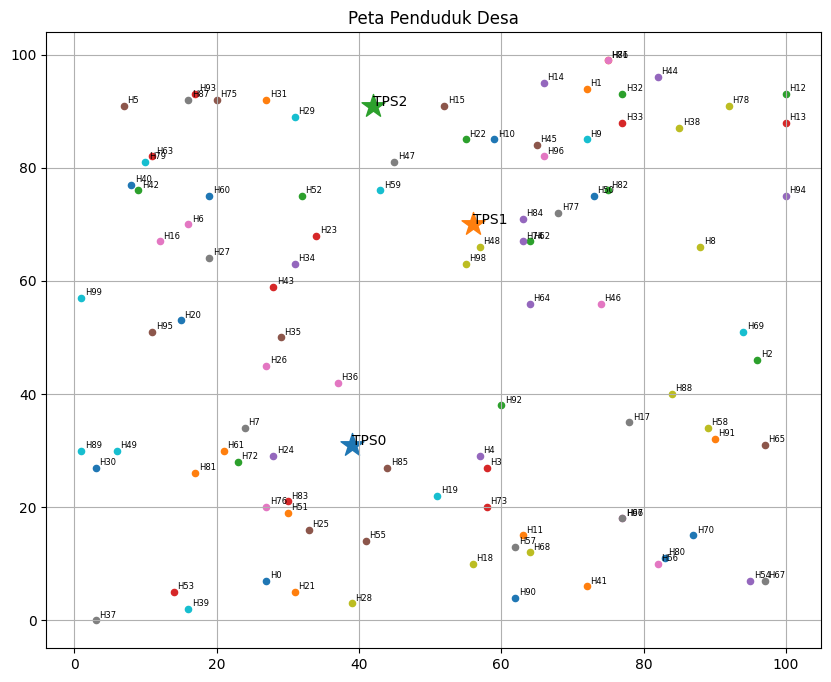

In [1]:
import random
import heapq
import math

jumlah_rumah = 100
jumlah_tps = 3
total_gerobak = random.randint(5, 7)
total_truk = random.randint(2, 4)
kapasitas_gerobak = 15
kapasitas_truk = 200
gerobak_mulai = 6 * 60
gerobak_selesai = 15 * 60
truk_mulai = 8 * 60
truk_selesai = 17 * 60

class House:
    def __init__(self, id):
        self.id = f"H{id}"
        self.x = random.randint(0,100)
        self.y = random.randint(0,100)
        self.waste = random.randint(0,7) 
class TPS:
    def __init__(self, id):
        self.id = id
        self.x = random.randint(0,100)
        self.y = random.randint(0,100)
        self.capacity = random.randint(400,500)
        self.current = 0

# untuk assignment rumah ke truk/gerobak
class Vehicle:
    def __init__(self, name, vtype, home_tps):
        self.name = name
        self.vtype = vtype
        self.home_tps = home_tps # zona utamanya
        self.position = home_tps
        self.load = 0 # isi muatan saat ini
        self.cargo_detail = {}
        self.distance = 0
        self.time_used = 0
        self.log = []
        self.start_time = gerobak_mulai if vtype == "gerobak" else truk_mulai
    def free_capacity(self): # sisa kapasitas yang bisa diisi
        if self.vtype == "gerobak":
            return kapasitas_gerobak - self.load
        return kapasitas_truk - self.load

# buat graph
graph = {}
all_nodes = []
houses = [House(i) for i in range(jumlah_rumah)]
total_sampah_awal = sum(h.waste for h in houses)
tps_nodes = [TPS(f"TPS{i}") for i in range(jumlah_tps)]
all_nodes.extend(houses)
all_nodes.extend(tps_nodes)
for node in all_nodes: # inisialisasi graph
    graph[node.id] = []
for node in all_nodes:
    neighbors = random.sample(
        [n for n in all_nodes if n.id != node.id],
        random.randint(2, 5)
    )
    for nb in neighbors:
        euclid = math.sqrt(
            (node.x - nb.x)**2 +
            (node.y - nb.y)**2
        )
        d = max(1, min(5, round(euclid / 20)))
        graph[node.id].append((nb.id, d))
        graph[nb.id].append((node.id, d))

# shortest path ucs
def shortest_path(start, goal):
    pq = [(0, start)]
    dist_map = {start: 0}

    while pq:
        cost, node = heapq.heappop(pq)

        if node == goal:
            return cost

        if cost > dist_map.get(node, float('inf')):
            continue

        for nxt, w in graph[node]:
            new_cost = cost + w
            if new_cost < dist_map.get(nxt, float('inf')):
                dist_map[nxt] = new_cost
                heapq.heappush(pq, (new_cost, nxt))

    return 999999

house_zone = {} # untuk menyimpan zona rumah, yaitu TPS terdekatnya
house_tps_distance = {}
for h in houses:
    nearest = None
    best_dist = 999999
    for tps in tps_nodes:
        d = shortest_path(h.id, tps.id)
        if d < best_dist: # jika jarak ke TPS ini lebih dekat, update zona rumah
            best_dist = d
            nearest = tps.id
    house_zone[h.id] = nearest
    house_tps_distance[h.id] = best_dist

def nearest_available_tps(vehicle):
    best = None
    best_cost = 999999
    for tps in tps_nodes:
        if tps.current >= tps.capacity:
            continue
        c = shortest_path(vehicle.position, tps.id)
        if c < best_cost:
            best_cost = c
            best = tps # simpan objek TPS terbaik
    return best, best_cost

def nearest_truck(vehicle):
    best = None
    best_dist = 999999
    for v in vehicles:
        if v.vtype != "truk":
            continue
        free = kapasitas_truk - v.load
        if free <= 0:
            continue
        d = shortest_path(vehicle.position, v.position)
        if d < best_dist:
            best_dist = d
            best = v

    return best, best_dist

def transfer_to_truck(gerobak):
    if gerobak.load <= 0:
        return False

    truck, dist = nearest_truck(gerobak)

    if truck is None:
        return False

    if dist > 1:
        return False

    if not move(gerobak, dist):
        return False

    free = kapasitas_truk - truck.load

    amount = min(gerobak.load, free)

    if amount <= 0:
        return False

    truck.load += amount
    gerobak.load -= amount
    gerobak.time_used += amount * 2

    for hid, kg in list(gerobak.cargo_detail.items()):
        take = min(kg, amount)

        truck.cargo_detail[hid] = (
            truck.cargo_detail.get(hid, 0)
            + take
        )

        gerobak.cargo_detail[hid] -= take

        if gerobak.cargo_detail[hid] <= 0:
            del gerobak.cargo_detail[hid]

        amount -= take

        if amount <= 0:
            break

    t = format_time(
        gerobak.start_time,
        gerobak.time_used
    )

    gerobak.log.append(
        f"{t} - titip sampah ke {truck.name}"
    )

    return True

def best_house(vehicle):

    best = None
    best_score = -999999
    best_dist = 0

    zone = vehicle.home_tps

    for h in houses:

        if h.waste <= 0:
            continue

        if house_zone[h.id] != zone:
            continue

        d = shortest_path(
            vehicle.position,
            h.id
        )

        score = h.waste / (d + 1)

        if score > best_score:
            best_score = score
            best = h
            best_dist = d

    return best, best_dist

def max_operating_time(vehicle):
    if vehicle.vtype == "gerobak":
        return gerobak_selesai - gerobak_mulai
    return truk_selesai - truk_mulai
def can_move(vehicle, dist):
    if vehicle.vtype == "gerobak":
        t = dist * 3
    else:
        t = dist * (3 / 5)
    return (
        vehicle.time_used + t
        <= max_operating_time(vehicle)
    )

# TIME
def move(vehicle, dist):
    if not can_move(vehicle, dist):
        return False
    vehicle.distance += dist
    if vehicle.vtype == "gerobak":
        t = dist * 3
    else:
        t = dist * (3 / 5)
    vehicle.time_used += t
    return True

def load_house(vehicle, house, dist):
    cap = vehicle.free_capacity() # sisa kapasitas yang bisa diisi
    take = min(cap, house.waste) # min untuk memastikan tidak mengambil lebih dari yang bisa diangkut atau yang tersedia di rumah
    if take <= 0:
        return False
    house.waste -= take
    vehicle.load += take
    vehicle.cargo_detail[house.id] = (vehicle.cargo_detail.get(house.id, 0) + take)
   
    t = format_time(vehicle.start_time, vehicle.time_used)
    vehicle.log.append(f"{t} - {vehicle.name} ambil {take}kg dari {house.id} | jarak: {dist}")
    return True

def dump_to_tps(vehicle):
    if vehicle.load <= 0:
        return
    tps, dist = nearest_available_tps(vehicle)
    if tps is None:
        return
    if not move(vehicle, dist):
        return
    vehicle.position = tps.id
    can_dump = min(vehicle.load, tps.capacity - tps.current)
    remaining = can_dump
    dumped_from = []
    for hid in list(vehicle.cargo_detail.keys()):
        if remaining <= 0:
            break
        amt = vehicle.cargo_detail[hid] # amt= jumlah yang diangkut dari rumah hid
        taken = min(amt, remaining) # jumlah yang diambil dari rumah ini untuk dibuang ke TPS
        dumped_from.append(f"{hid}:{taken}kg")
        vehicle.cargo_detail[hid] -= taken # update sisa yang diangkut dari rumah ini setelah dibuang ke TPS
        if vehicle.cargo_detail[hid] <= 0: # jika sudah habis, hapus dari cargo_detail
            del vehicle.cargo_detail[hid]
        remaining -= taken
    tps.current += can_dump
    vehicle.load -= can_dump
    if vehicle.vtype == "gerobak":
        vehicle.time_used += can_dump * 2
    else:
        vehicle.time_used += (can_dump / 10) * 2
    detail = ", ".join(dumped_from)
    t = format_time(vehicle.start_time, vehicle.time_used)
    vehicle.log.append(f"{t} - {vehicle.name} buang {can_dump}kg ke {tps.id}")

def format_time(start_minutes, elapsed):
    total = start_minutes + int(elapsed)
    h = total // 60
    m = total % 60
    return f"{h:02d}.{m:02d}"

vehicles = []

used_gerobak = 0
used_truk = 0

# 1. JAMIN MINIMAL 1 GEROBAK PER TPS
for tps in tps_nodes:
    if used_gerobak < total_gerobak:
        vehicles.append(Vehicle(f"G{used_gerobak}", "gerobak", tps.id))
        used_gerobak += 1

# 2. JAMIN MINIMAL 1 TRUK PER TPS
for tps in tps_nodes:
    if used_truk < total_truk:
        vehicles.append(Vehicle(f"T{used_truk}", "truk", tps.id))
        used_truk += 1

# 3. SISA GEROBAK RANDOM
for i in range(used_gerobak, total_gerobak):
    tps = random.choice(tps_nodes)
    vehicles.append(Vehicle(f"G{i}", "gerobak", tps.id))

# 4. SISA TRUK RANDOM
for i in range(used_truk, total_truk):
    tps = random.choice(tps_nodes)
    vehicles.append(Vehicle(f"T{i}", "truk", tps.id))

def operate_one_step(vehicle):

    max_time = (
        gerobak_selesai - gerobak_mulai
        if vehicle.vtype == "gerobak"
        else truk_selesai - truk_mulai
    )

    if vehicle.time_used >= max_time:
        return

    house, dist = best_house(vehicle)

    if house is None:

        if vehicle.vtype == "gerobak":
            if not transfer_to_truck(vehicle):
                dump_to_tps(vehicle)
        else:
            dump_to_tps(vehicle)
        return

    if not move(vehicle, dist):
        return

    vehicle.position = house.id

    if not load_house(vehicle, house, dist):
        return

    # kalau sudah penuh atau rumah habis
    if vehicle.free_capacity() == 0:
        dump_to_tps(vehicle)

    elif vehicle.load > 0:
        dump_to_tps(vehicle)

active = True
iteration = 0
max_iter = 10000
while active and iteration < max_iter:
    iteration += 1
    active = False
    for v in vehicles:
        before = v.time_used
        operate_one_step(v)
        if v.time_used > before:
            active = True

sisa_rumah = sum(h.waste for h in houses)
sisa_truk = sum(v.load for v in vehicles if v.vtype == "truk")
sisa_gerobak = sum(v.load for v in vehicles if v.vtype == "gerobak")
tidak_sampai_tps = (sisa_rumah + sisa_truk + sisa_gerobak)
total_truk_distance = 0
total_gerobak_distance = 0
total_truk_time = 0
total_gerobak_time = 0

for v in vehicles:
    if v.vtype == "truk":
        total_truk_distance += v.distance
        total_truk_time += v.time_used
    else:
        total_gerobak_distance += v.distance
        total_gerobak_time += v.time_used

# REPORT
print("Total sampah awal:", total_sampah_awal)
print("\nTPS ")
for t in tps_nodes:
    print(t.id, "isi:", t.current, "/", t.capacity)

print("\nkendaraan ")
total_distance = 0
for v in vehicles:
    total_distance += v.distance
    print( v.name, "| waktu:", round(v.time_used, 2), "| jarak:", v.distance, "| sisa muatan:", v.load, "kg", "| zona:", v.home_tps)
print("\ntotal jarak semua kendaraan:", total_distance)
print("total jarak truk:", total_truk_distance)
print("total jarak gerobak:", total_gerobak_distance)
print("total waktu truk:", total_truk_time)
print("total waktu gerobak:", total_gerobak_time)
remain = sum(h.waste for h in houses)
print("\nSisa sampah rumah: ", remain)
print("\nSampah tidak sampai TPS:", tidak_sampai_tps)


print("\nlog aktivitas kendaraan")
for v in vehicles:
    print("\n", v.name)
    for item in v.log[:20]:
        print(item)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

for h in houses:
    plt.scatter(h.x, h.y, s=20)
    plt.text(h.x + 0.5, h.y + 0.5, h.id, fontsize=6)

for t in tps_nodes:
    plt.scatter(
        t.x,
        t.y,
        marker="*",
        s=300
    )
    plt.text(t.x, t.y, t.id)

plt.title("Peta Penduduk Desa")
plt.grid(True)
plt.show()

## 4.2 Hasil Simulasi

Setelah program dijalankan, sistem menghasilkan informasi berupa:

- Jumlah sampah yang berhasil dikumpulkan.
- Sisa sampah yang belum terangkut.
- Total jarak tempuh setiap kendaraan.
- Waktu operasional kendaraan.
- Kapasitas TPS yang terisi.
- Log aktivitas kendaraan selama simulasi berlangsung.

Hasil simulasi menunjukkan bahwa penggunaan algoritma UCS mampu membantu kendaraan menemukan jalur dengan biaya perjalanan paling kecil sehingga proses pengangkutan sampah menjadi lebih efisien.

## 4.3 Analisis Hasil

hasil simulasi, algoritma Uniform Cost Search mampu menentukan rute perjalanan dengan biaya minimum berdasarkan bobot jarak pada graph. Gerobak dapat mengumpulkan sampah dari rumah-rumah dan mengangkutnya menuju TPS sesuai kapasitas yang tersedia.

Pembagian zona berdasarkan TPS terdekat membantu mengurangi jarak perjalanan kendaraan karena setiap kendaraan lebih banyak melayani wilayah yang berada di sekitar TPS asalnya. Selain itu, pembatasan waktu operasional membuat simulasi lebih realistis karena kendaraan tidak dapat bekerja tanpa batas waktu.

Visualisasi peta menunjukkan bahwa persebaran rumah cukup merata terhadap tiga TPS yang tersedia sehingga proses pengumpulan sampah dapat dilakukan dengan baik. Apabila masih terdapat sisa sampah pada akhir simulasi, hal tersebut disebabkan oleh keterbatasan kapasitas kendaraan atau waktu operasional yang telah habis.

Secara keseluruhan, simulasi berhasil menunjukkan bagaimana konsep Artificial Intelligence, graph, dan algoritma Uniform Cost Search dapat diterapkan untuk membantu pengelolaan sampah secara lebih efisien.

# BAB V PENUTUP

## 5.1 Kesimpulan

hasil perancangan dan implementasi sistem simulasi pengelolaan sampah desa, dapat disimpulkan bahwa algoritma Uniform Cost Search (UCS) berhasil diterapkan untuk menentukan rute pengangkutan sampah dengan biaya perjalanan minimum. Sistem mampu mensimulasikan proses pengumpulan sampah dari 100 rumah penduduk menuju TPS menggunakan gerobak dan truk sampah sesuai kapasitas serta waktu operasional yang telah ditentukan.

Penggunaan graph sebagai representasi jalan desa memudahkan proses pencarian jalur terpendek antar lokasi. Selain itu, pembagian wilayah berdasarkan TPS terdekat membantu meningkatkan efisiensi pengangkutan karena kendaraan dapat fokus pada area layanan masing-masing.

Hasil simulasi menunjukkan bahwa kendaraan mampu mengangkut sebagian besar sampah yang dihasilkan penduduk dengan memperhatikan kapasitas kendaraan, kapasitas TPS, serta batas waktu operasional. Dengan demikian, penerapan algoritma UCS pada sistem pengelolaan sampah dapat membantu menghasilkan proses pengangkutan yang lebih efektif dan terorganisir.

## 5.2 Saran
Beberapa saran untuk pengembangan sistem di masa mendatang adalah sebagai berikut:

1. Menambahkan data peta yang lebih realistis menggunakan koordinat lokasi sebenarnya sehingga simulasi mendekati kondisi lapangan.
2. Mengimplementasikan algoritma optimasi lain seperti A* Search atau Genetic Algorithm untuk membandingkan performa dengan Uniform Cost Search.
3. Menambahkan faktor kemacetan, kondisi jalan, dan waktu tempuh dinamis agar simulasi lebih realistis.
4. Menambahkan visualisasi pergerakan kendaraan secara real-time sehingga proses pengangkutan sampah dapat dipantau dengan lebih mudah.
5. Mengembangkan sistem menjadi aplikasi berbasis web atau mobile yang dapat digunakan sebagai alat bantu pengambilan keputusan dalam pengelolaan sampah desa.